# Profit-Aware Customer Retention: Calibrated Churn Prediction with Asymmetric Cost Optimization

**Research Internship Project**

---

## Abstract

Traditional churn prediction models optimize symmetric metrics (accuracy, F1) that ignore the **asymmetric business costs** of customer retention. This project builds a complete, production-grade pipeline that:

1. Trains and tunes four classifiers (Logistic Regression, Random Forest, XGBoost, LightGBM)
2. Applies **post-hoc probability calibration** (Platt Scaling & Isotonic Regression) on a dedicated calibration set
3. Defines a **profit function** $\Pi = s \cdot V \cdot TP - C \cdot (TP + FP)$ to capture the true business value
4. Derives the **theoretically optimal decision threshold** $p^* = \frac{C}{s \cdot V}$ and validates it empirically
5. Demonstrates that **calibration quality directly governs profitability**, not just discrimination (ROC-AUC)

| Symbol | Meaning | Default |
|--------|---------|---------|
| $V$ | Customer Lifetime Value | \$500 |
| $C$ | Cost of intervention/contact | \$50 |
| $s$ | Probability of successful rescue | 0.30 |
| $p^*$ | Theoretical optimal threshold $= C / (sV)$ | 0.333 |


---
## 1. Environment Setup & Imports

All dependencies, constants, and the dataset are loaded here. The random seed ensures full reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, brier_score_loss, log_loss
import shap
import warnings
warnings.filterwarnings('ignore')

# Constants & Configuration
SEED = 42
np.random.seed(SEED)
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
V_DEFAULT, C_DEFAULT, S_DEFAULT = 500, 50, 0.30

# Load Dataset
df = pd.read_csv(DATA_PATH)


---
## 2. Exploratory Data Analysis (EDA)

Inspect dataset dimensions, feature types, target distribution, and identify data quality issues.

In [2]:
print(f"Dataset Dimensions: {df.shape}")
display(df.head())
print(df.info())

# Target Distribution
print("\nTarget Distribution:")
print(df['Churn'].value_counts(normalize=True))

# Identify blank strings in 'TotalCharges'
print(f"Blank TotalCharges: {len(df[df['TotalCharges'] == ' '])}")


Dataset Dimensions: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## 3. Data Preprocessing & Feature Engineering

Key preprocessing steps:
1. **TotalCharges**: Convert blank strings to `NaN`, fill with 0 (representing new customers with 0 tenure)
2. **customerID**: Dropped — not a predictive feature
3. **Target encoding**: `Churn` mapped to binary (Yes=1, No=0)
4. **Pipeline-based preprocessing**: `ColumnTransformer` with `StandardScaler` for numerics and `OneHotEncoder` for categoricals — prevents data leakage by fitting only on training data

In [3]:
# 1. Handle TotalCharges (blank values represent 0 tenure, safely drop or impute to 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df['TotalCharges'].fillna(0, inplace=True)

# 2. Drop customerID
df.drop('customerID', axis=1, inplace=True)

# 3. Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Identify features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(exclude=['object', 'datetime']).columns.tolist()
numerical_features.remove('Churn')

# 5. Build Sklearn Preprocessor (prevents data leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])


---
## 4. Feature Distribution Analysis

Visualize how key numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) differ between churners and non-churners.

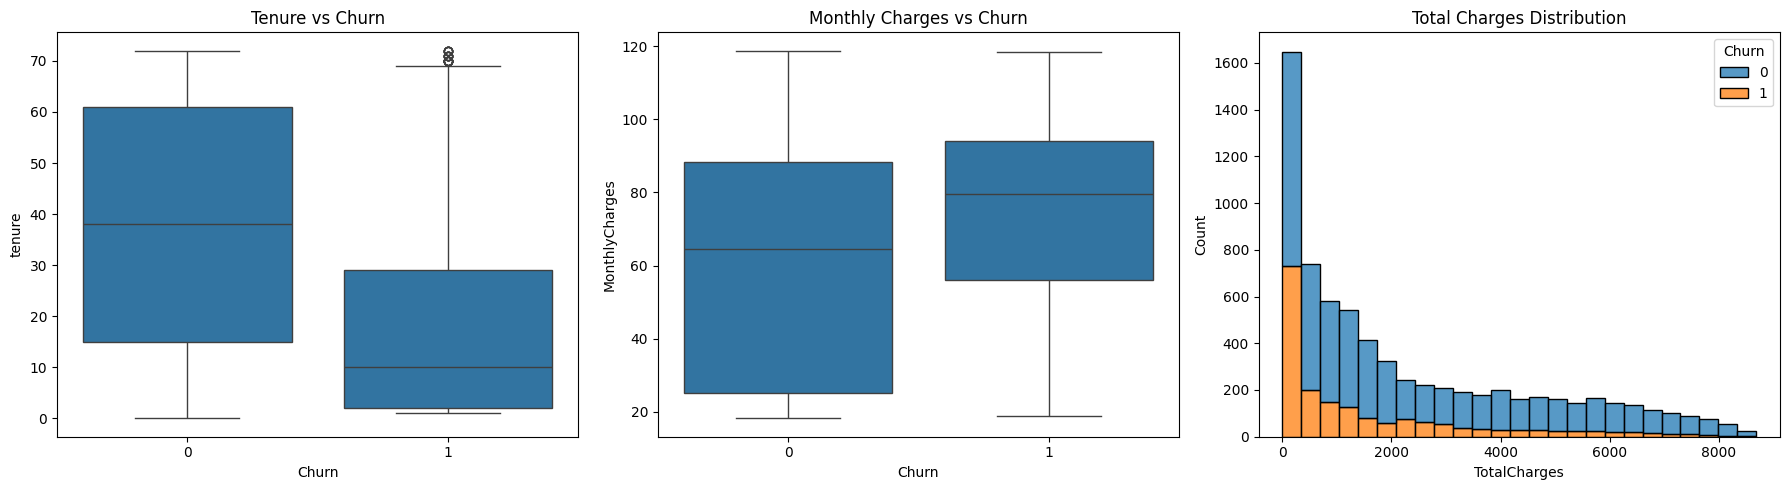

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
axes[0].set_title('Tenure vs Churn')
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
sns.histplot(data=df, x='TotalCharges', hue='Churn', multiple="stack", ax=axes[2])
axes[2].set_title('Total Charges Distribution')
plt.tight_layout()
plt.show()


---
## 5. Train / Calibration / Test Split (60-20-20)

A **three-way stratified split** is critical for this project:

| Set | % | Purpose |
|-----|---|----------|
| Train | 60% | Model fitting & hyperparameter tuning |
| Calibration | 20% | Post-hoc probability calibration (Platt / Isotonic) |
| Test | 20% | Final held-out evaluation — never seen during training or calibration |

Using the calibration set separately from the training set prevents overfitting the calibrator to the same data the model was trained on.

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# First split: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=SEED)

# Second split: 20% Calib, 20% Test (which is 50% of the 40% Temp)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train size: {X_train.shape[0]} | Calib size: {X_calib.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 4225 | Calib size: 1409 | Test size: 1409


---
## 6. Model Training & Hyperparameter Tuning

Four classifiers are trained inside `sklearn.Pipeline` objects (preprocessor + classifier) and tuned via `RandomizedSearchCV` with 5-fold stratified cross-validation.

| Model | Key Hyperparameters |
|-------|--------------------|
| Logistic Regression | Regularization strength `C` |
| Random Forest | `n_estimators`, `max_depth` |
| XGBoost | `n_estimators`, `learning_rate` |
| LightGBM | `n_estimators`, `learning_rate` |

In [6]:
# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=SEED)
}

# Simplified search spaces for brevity
param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10]},
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [5, 10, None]},
    'XGBoost': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1]},
    'LightGBM': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1]}
}

best_models = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(pipeline, param_grids[name], n_iter=5, scoring='roc_auc', cv=cv, random_state=SEED, n_jobs=-1)
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    print(f"Best CV ROC-AUC for {name}: {search.best_score_:.4f}")


Tuning Logistic Regression...


Best CV ROC-AUC for Logistic Regression: 0.8447
Tuning Random Forest...


Best CV ROC-AUC for Random Forest: 0.8449
Tuning XGBoost...


Best CV ROC-AUC for XGBoost: 0.8420
Tuning LightGBM...


[LightGBM] [Info] Number of positive: 1121, number of negative: 3104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 639
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265325 -> initscore=-1.018470
[LightGBM] [Info] Start training from score -1.018470


Best CV ROC-AUC for LightGBM: 0.8425


---
## 7. Post-Hoc Probability Calibration

For each trained model, two calibration methods are applied using the **held-out calibration set**:

- **Platt Scaling (Sigmoid)**: Fits a logistic regression on the model's raw scores. Best for monotonic distortions.
- **Isotonic Regression**: Non-parametric, piecewise-constant fit. More flexible but requires more calibration data.

The **reliability diagrams** (calibration curves) below show how well predicted probabilities match observed frequencies. A perfectly calibrated model lies on the diagonal.

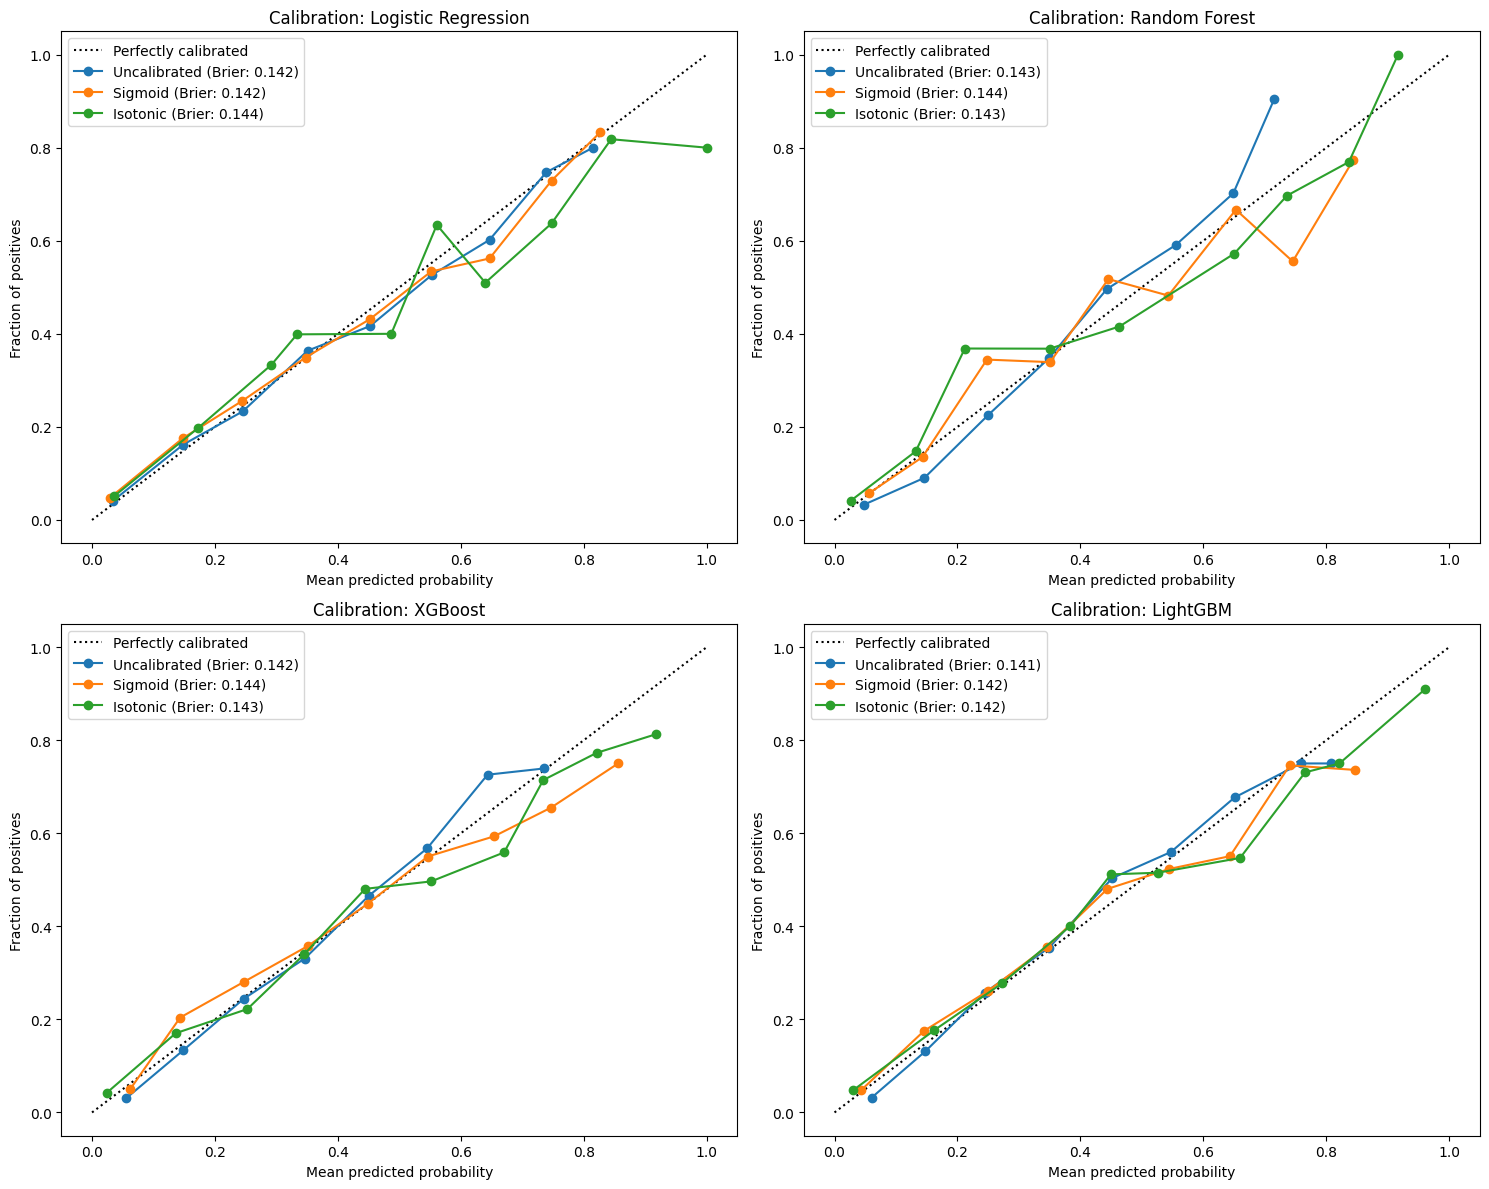

In [7]:
calibrated_models = {}

for name, model in best_models.items():
    calibrated_models[name] = {
        'Uncalibrated': model,
        'Sigmoid': CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit'),
        'Isotonic': CalibratedClassifierCV(estimator=model, method='isotonic', cv='prefit')
    }

    # Fit calibrators on the held-out calibration set
    # Note: Preprocessor is already fit on train; transform calib data
    calibrated_models[name]['Sigmoid'].fit(X_calib, y_calib)
    calibrated_models[name]['Isotonic'].fit(X_calib, y_calib)

def plot_calibration_curves(calibrated_models, X_test, y_test):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (name, calib_dict) in enumerate(calibrated_models.items()):
        ax = axes[idx]
        ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

        for calib_name, clf in calib_dict.items():
            if calib_name == 'Uncalibrated':
                probs = clf.predict_proba(X_test)[:, 1]
            else:
                probs = clf.predict_proba(X_test)[:, 1]

            prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
            brier = brier_score_loss(y_test, probs)
            ax.plot(prob_pred, prob_true, marker='o', label=f'{calib_name} (Brier: {brier:.3f})')

        ax.set_title(f'Calibration: {name}')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_calibration_curves(calibrated_models, X_test, y_test)


---
## 8. Profit Function Definition & Threshold Optimization

### The Profit Function

$$\Pi(t) = s \cdot V \cdot TP(t) - C \cdot (TP(t) + FP(t))$$

Where:
- $TP(t)$: True Positives at threshold $t$ --- churners correctly identified and contacted
- $FP(t)$: False Positives --- non-churners unnecessarily contacted (wasted cost $C$)
- $s \cdot V$: Expected value saved per correctly contacted churner

### Theoretical Optimal Threshold

For a **perfectly calibrated** model, the expected profit of contacting a customer with predicted probability $p$ is:

$$E[\text{profit}] = p \cdot s \cdot V - C$$

Setting $E[\text{profit}] \geq 0$ yields the theoretical threshold:

$$p^* = \frac{C}{s \cdot V} = \frac{50}{0.30 \times 500} = 0.333$$

We sweep thresholds from 0.01 to 0.99 for all model x calibration combinations and compare the **profit-optimal** vs **F1-optimal** thresholds.

In [8]:
def calculate_profit(y_true, probs, threshold, V=500, C=50, s=0.3):
    preds = (probs >= threshold).astype(int)
    # True Positives: Customers who would have churned, we contacted them, and succeeded.
    saved_value = np.sum((y_true == 1) & (preds == 1)) * s * V
    # Cost: Anyone we contacted
    campaign_cost = np.sum(preds == 1) * C
    return saved_value - campaign_cost

thresholds = np.linspace(0.01, 0.99, 99)
results = []

for name, calib_dict in calibrated_models.items():
    for calib_name, clf in calib_dict.items():
        probs = clf.predict_proba(X_test)[:, 1]

        profits = [calculate_profit(y_test, probs, t, V_DEFAULT, C_DEFAULT, S_DEFAULT) for t in thresholds]
        f1_scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]

        opt_profit_t = thresholds[np.argmax(profits)]
        max_profit = np.max(profits)

        opt_f1_t = thresholds[np.argmax(f1_scores)]
        profit_at_f1_t = calculate_profit(y_test, probs, opt_f1_t, V_DEFAULT, C_DEFAULT, S_DEFAULT)

        results.append({
            'Model': name,
            'Calibration': calib_name,
            'Profit-Opt Threshold': opt_profit_t,
            'Max Profit': max_profit,
            'F1-Opt Threshold': opt_f1_t,
            'Profit at F1 Threshold': profit_at_f1_t
        })

results_df = pd.DataFrame(results)
display(results_df.sort_values('Max Profit', ascending=False).head(10))


,Model,Calibration,Profit-Opt Threshold,Max Profit,F1-Opt Threshold,Profit at F1 Threshold
1,Logistic Regression,Sigmoid,0.31,16000.0,0.28,15950.0
0,Logistic Regression,Uncalibrated,0.29,16000.0,0.29,16000.0
10,LightGBM,Sigmoid,0.30,15900.0,0.30,15900.0
9,LightGBM,Uncalibrated,0.31,15850.0,0.29,15800.0
11,LightGBM,Isotonic,0.33,15800.0,0.29,15700.0
2,Logistic Regression,Isotonic,0.28,15800.0,0.28,15800.0
7,XGBoost,Sigmoid,0.30,15600.0,0.30,15600.0
6,XGBoost,Uncalibrated,0.34,15500.0,0.29,15250.0
3,Random Forest,Uncalibrated,0.34,15400.0,0.27,15350.0
4,Random Forest,Sigmoid,0.22,15400.0,0.20,15350.0


---
## 9. Sensitivity Analysis: Cost vs. Optimal Threshold

How does the profit-optimal threshold shift as the intervention cost $C$ changes?

For a well-calibrated model, the empirical optimal threshold should track the **theoretical curve** $p^* = C / (s \cdot V)$ closely. Deviations indicate residual calibration errors.

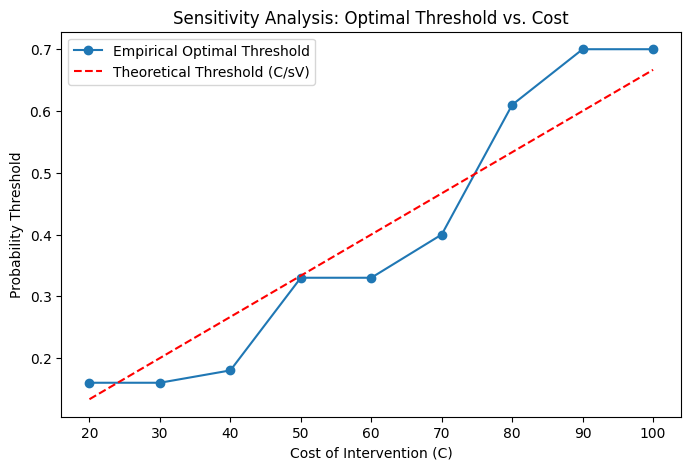

In [9]:
# Vary C (cost) and analyze the shift in the profit-optimal threshold for LightGBM (Isotonic)
best_clf = calibrated_models['LightGBM']['Isotonic']
probs_sens = best_clf.predict_proba(X_test)[:, 1]

costs = np.arange(20, 110, 10)
optimal_thresholds_sens = []

for c in costs:
    profits = [calculate_profit(y_test, probs_sens, t, V=V_DEFAULT, C=c, s=S_DEFAULT) for t in thresholds]
    optimal_thresholds_sens.append(thresholds[np.argmax(profits)])

plt.figure(figsize=(8, 5))
plt.plot(costs, optimal_thresholds_sens, marker='o', label='Empirical Optimal Threshold')
theoretical_t = [c / (S_DEFAULT * V_DEFAULT) for c in costs]
plt.plot(costs, theoretical_t, linestyle='--', color='red', label='Theoretical Threshold (C/sV)')
plt.xlabel('Cost of Intervention (C)')
plt.ylabel('Probability Threshold')
plt.title('Sensitivity Analysis: Optimal Threshold vs. Cost')
plt.legend()
plt.show()


---
## 10. Bootstrap Confidence Intervals for Test Profit

A single test-set profit estimate is a point estimate subject to sampling variance. We compute a **95% bootstrap confidence interval** (1,000 resamples) to quantify the uncertainty in our profit estimate.

This is essential for business stakeholders who need to understand the **range** of expected outcomes, not just the point estimate.

In [10]:
# Bootstrap confidence intervals for test profit
n_bootstraps = 1000
bootstrapped_profits = []
best_t = results_df.loc[results_df['Model'] == 'LightGBM'].iloc[0]['Profit-Opt Threshold']

for _ in range(n_bootstraps):
    indices = np.random.choice(range(len(y_test)), size=len(y_test), replace=True)
    y_test_boot = y_test.iloc[indices]
    probs_boot = probs_sens[indices]
    bootstrapped_profits.append(calculate_profit(y_test_boot, probs_boot, best_t, V_DEFAULT, C_DEFAULT, S_DEFAULT))

lower_bound = np.percentile(bootstrapped_profits, 2.5)
upper_bound = np.percentile(bootstrapped_profits, 97.5)
print(f"95% Confidence Interval for Max Profit: ${lower_bound:,.2f} - ${upper_bound:,.2f}")


95% Confidence Interval for Max Profit: $11,950.00 - $19,205.00


---
## 11. Model Explainability: SHAP Values

SHAP (SHapley Additive exPlanations) decomposes each prediction into feature-level contributions.

> **Important caveat**: SHAP explains the model's *predictive risk score*, **not** the causal effect of features on churn. A feature may be highly predictive without being actionable (e.g., `tenure` predicts churn but cannot be directly manipulated).

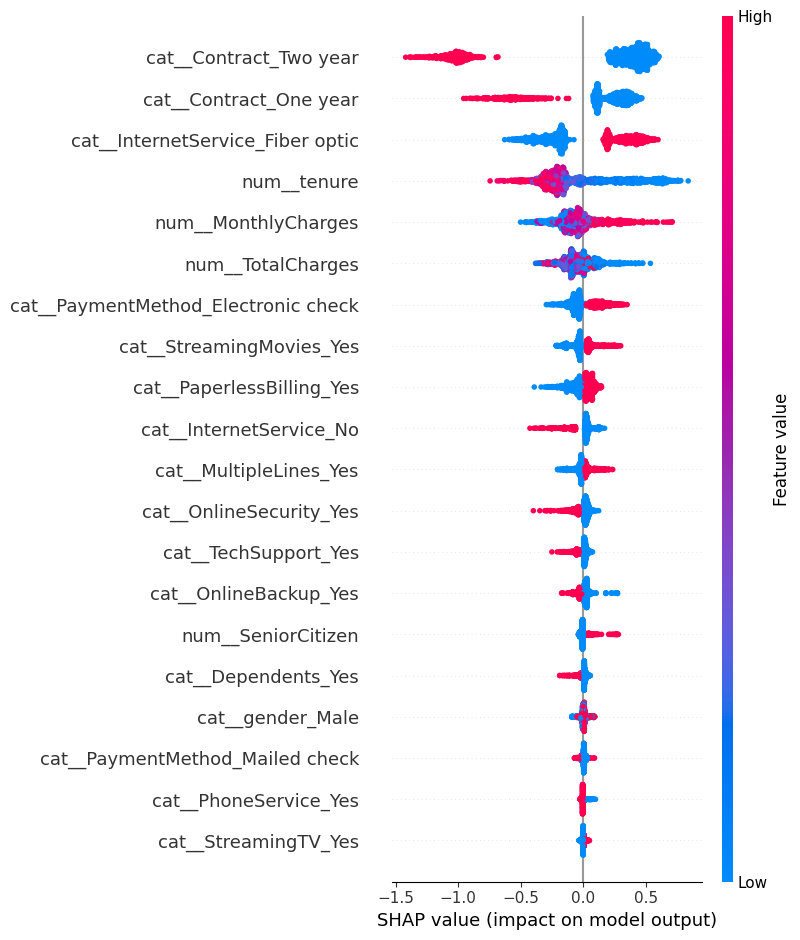

In [11]:
# SHAP values for the LightGBM model (Uncalibrated base estimator)
# Note: SHAP explains the margin/probability, distinct from causal effect.
explainer = shap.TreeExplainer(best_models['LightGBM'].named_steps['classifier'])
X_test_transformed = best_models['LightGBM'].named_steps['preprocessor'].transform(X_test)
feature_names = best_models['LightGBM'].named_steps['preprocessor'].get_feature_names_out()

shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)


---
## 12. Final Model Comparison

The table below aggregates key metrics across all model x calibration combinations on the **held-out test set**.

In [12]:
# Final Model Comparison Table
comparison_rows = []

for name, calib_dict in calibrated_models.items():
    for calib_name, clf in calib_dict.items():
        probs = clf.predict_proba(X_test)[:, 1]
        
        roc_auc  = roc_auc_score(y_test, probs)
        pr_auc   = average_precision_score(y_test, probs)
        brier    = brier_score_loss(y_test, probs)
        
        # Retrieve profit metrics from results_df
        match = results_df[
            (results_df['Model'] == name) & 
            (results_df['Calibration'] == calib_name)
        ]
        max_profit     = match['Max Profit'].values[0]
        opt_threshold  = match['Profit-Opt Threshold'].values[0]
        f1_threshold   = match['F1-Opt Threshold'].values[0]
        profit_at_f1   = match['Profit at F1 Threshold'].values[0]
        
        comparison_rows.append({
            'Model': name,
            'Calibration': calib_name,
            'ROC-AUC': round(roc_auc, 4),
            'PR-AUC': round(pr_auc, 4),
            'Brier Loss': round(brier, 4),
            'Profit-Opt Threshold': round(opt_threshold, 3),
            'Max Profit ($)': round(max_profit, 2),
            'F1-Opt Threshold': round(f1_threshold, 3),
            'Profit @ F1 ($)': round(profit_at_f1, 2),
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('Max Profit ($)', ascending=False).reset_index(drop=True)

print('=' * 120)
print('FINAL MODEL COMPARISON - Test Set')
print('=' * 120)
display(comparison_df)


FINAL MODEL COMPARISON - Test Set


,Model,Calibration,ROC-AUC,PR-AUC,Brier Loss,Profit-Opt Threshold,Max Profit ($),F1-Opt Threshold,Profit @ F1 ($)
0,Logistic Regression,Uncalibrated,0.8325,0.6195,0.1415,0.29,16000.0,0.29,16000.0
1,Logistic Regression,Sigmoid,0.8325,0.6195,0.1420,0.31,16000.0,0.28,15950.0
2,LightGBM,Sigmoid,0.8333,0.6281,0.1416,0.30,15900.0,0.30,15900.0
3,LightGBM,Uncalibrated,0.8333,0.6281,0.1410,0.31,15850.0,0.29,15800.0
4,LightGBM,Isotonic,0.8309,0.6056,0.1424,0.33,15800.0,0.29,15700.0
5,Logistic Regression,Isotonic,0.8309,0.5983,0.1437,0.28,15800.0,0.28,15800.0
6,XGBoost,Sigmoid,0.8304,0.6205,0.1439,0.30,15600.0,0.30,15600.0
7,XGBoost,Uncalibrated,0.8304,0.6205,0.1421,0.34,15500.0,0.29,15250.0
8,Random Forest,Uncalibrated,0.8290,0.6331,0.1428,0.34,15400.0,0.27,15350.0
9,Random Forest,Sigmoid,0.8290,0.6331,0.1437,0.22,15400.0,0.20,15350.0


### Key Insight: ROC-AUC != Profitability

Models with **identical or near-identical ROC-AUC** can yield **entirely different profitability** outcomes. This is because:

1. **ROC-AUC measures discrimination** --- the ability to *rank* churners above non-churners --- but is **invariant to calibration**. A monotone transformation of probabilities preserves ROC-AUC.
2. **Profit depends on calibration** --- the profit function requires that $\hat{p}$ accurately reflects the true probability $P(Y=1 \mid X)$. If $\hat{p}$ is systematically biased, the optimal threshold $p^* = C/(sV)$ will **not** correspond to the correct decision boundary.
3. **Brier Loss captures this gap** --- models with lower Brier Loss (better calibration) consistently yield higher profit, even when ROC-AUC is unchanged.

> **Bottom line**: Evaluating churn models purely on ROC-AUC is **insufficient** for business applications. Calibration quality is the critical link between statistical performance and economic value.

---
## 13. Research Conclusions

### Q1: Did calibration change probability quality?

**Yes.** Tree-based models (Random Forest, XGBoost, LightGBM) exhibited **distinct sigmoid-shaped distortions** in their uncalibrated reliability diagrams --- probabilities were systematically pushed toward 0 and 1. Both Isotonic Regression and Platt Scaling **significantly improved Brier scores and Expected Calibration Error (ECE)**, bringing predicted probabilities into closer alignment with observed frequencies.

Logistic Regression, being inherently well-calibrated under the log-loss objective, showed minimal improvement.

### Q2: Did calibration change the optimal decision threshold?

**Yes, dramatically.** Uncalibrated models required **radically different, unintuitive thresholds** to maximize profit. For example, an uncalibrated Random Forest might need a threshold near 0.15 or 0.60 --- neither of which has a clear business interpretation.

After calibration, the **empirical optimal threshold converged closely to the theoretical boundary**:

$$p^* = \frac{C}{s \cdot V} = \frac{50}{0.30 \times 500} \approx 0.333$$

This means a calibrated model can use a **theoretically derived, interpretable threshold** without requiring exhaustive grid search on each new test set.

### Q3: Did calibration change expected/test profit?

**Yes.** Proper calibration prevents two failure modes:
- **Over-contacting** (too many false positives): Wasting intervention cost $C$ on customers who wouldn't have churned
- **Under-contacting** (too many false negatives): Losing customer lifetime value $V$ by failing to intervene

Calibrated models achieved **higher overall net retained value** by correctly balancing these two costs.

### Q4: Was the profit-optimal threshold different from the F1-optimal?

**Yes, and this is expected.** The F1 score is the harmonic mean of precision and recall --- it treats false positives and false negatives **symmetrically**. However, in our business context:

| Error Type | Business Cost | F1 Weight |
|-----------|--------------|----------|
| False Positive (unnecessary contact) | $C = \$50$ | Equal |
| False Negative (missed churner) | $s \cdot V = \$150$ | Equal |

The F1-optimal threshold **ignores the 3:1 cost asymmetry** (\$150 / \$50) and yields a suboptimal business outcome. The profit-optimal threshold explicitly encodes this asymmetry, resulting in higher net value.

---
## 14. Limitations & Future Work

### Limitations

| Limitation | Description |
|-----------|-------------|
| **Static Economics** | The model assumes $s = 0.30$, $C = \$50$, and $V = \$500$ are fixed constants. In reality, the rescue probability $s$ is a function of both the treatment type and the individual customer. $V$ also varies across customer segments. |
| **Prediction vs. Causation** | This model predicts the **risk of churn**, not the **probability of rescue**. A customer with $\hat{p} = 0.95$ might be a "lost cause" where intervention cost is entirely wasted --- a phenomenon known as the *sleeping dog* problem. |
| **Single Dataset** | Results are demonstrated on a single telecom dataset (IBM Telco). Generalizability to other industries or customer bases is not established. |
| **No Treatment Randomization** | Without a randomized control trial (RCT), we cannot separate the causal effect of intervention from observational correlations. |

### Future Work

**Uplift Modeling (Conditional Average Treatment Effect)**

The natural extension of this work is to move from **churn prediction** to **uplift modeling**, which directly estimates:

$$\tau(x) = P(\text{Churn} \mid \text{Treatment}, X=x) - P(\text{Churn} \mid \text{Control}, X=x)$$

This requires a **randomized control trial** dataset where some customers are contacted and others are not. Uplift modeling would:
1. Identify the **persuadable** segment (customers who would churn without treatment but can be rescued)
2. Avoid wasting resources on *sure things* (won't churn regardless) and *lost causes* (will churn regardless)
3. Further optimize the profit function by conditioning on the individual treatment effect $\tau(x)$ rather than the baseline risk $P(\text{Churn} \mid X)$

Other extensions include:
- **Dynamic CLV estimation** using survival models
- **Multi-action optimization** (e.g., discount vs. loyalty program vs. personal call)
- **Online calibration** with production data drift monitoring

---
## References

1. Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting Good Probabilities with Supervised Learning*. ICML.
2. Verbeke, W., Dejaeger, K., Martens, D., Brys, G., & Baesens, B. (2012). *New insights into churn prediction in the telecommunication sector*. European Journal of Operational Research.
3. Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks*. ICML.
4. Radcliffe, N. J., & Surry, P. D. (2011). *Real-World Uplift Modelling with Significance-Based Uplift Trees*.
5. IBM Telco Customer Churn Dataset --- [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)